In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches
import numpy as np
import warnings

warnings.filterwarnings('ignore')

In [5]:
# laod data
file_name = 'clean_BE_df.parquet'

data = pd.read_parquet(file_name)
data.head(n=15)

,Pieces,Minifigs,Retail,Value,LEGO,Amazon,Bricklink,StockX,eBay,Years
75268 Snowspeeder,91,2,19.99,27.63,0,1,1,0,1,5
75235 X-wing Starfighter Trench Run,132,4,29.99,40.00,0,1,1,1,1,6
75237 TIE Fighter Attack,77,2,19.99,43.41,0,1,1,1,1,6
75247 Rebel A-wing Starfighter,62,2,14.99,29.23,0,1,1,0,1,6
75416 Chopper (C1-10P) Astromech Droid,1039,1,99.99,99.99,1,1,0,1,1,0
75412 Death Trooper & Night Trooper Battle Pack,119,4,22.99,22.99,1,0,0,0,1,0
75385 Battle on Peridea,382,5,54.99,48.17,0,1,0,1,1,1
75357 Ghost & Phantom II,1394,4,159.99,159.99,1,1,0,1,1,2
75364 New Republic E-wing vs. Shin Hati's Starfighter,1056,5,109.99,97.88,0,1,0,1,1,2
75362 Ahsoka Tano's T-6 Jedi Shuttle,599,4,79.99,65.00,0,1,0,1,1,2


In [6]:
data.describe()

,Pieces,Minifigs,Retail,Value,LEGO,Amazon,Bricklink,StockX,eBay,Years
count,655.000000,655.000000,655.000000,655.000000,655.000000,655.00000,655.000000,655.000000,655.000000,655.000000
mean,525.955725,3.334351,61.294580,256.003313,0.091603,0.91145,0.682443,0.613740,0.989313,10.328244
std,775.766185,3.471989,87.105011,685.918738,0.288685,0.28431,0.465882,0.487263,0.102903,7.003759
min,2.000000,0.000000,3.990000,3.990000,0.000000,0.00000,0.000000,0.000000,0.000000,-1.000000
25%,107.500000,1.000000,19.990000,45.155000,0.000000,1.00000,0.000000,0.000000,1.000000,5.000000
50%,292.000000,3.000000,39.990000,93.310000,0.000000,1.00000,1.000000,1.000000,1.000000,9.000000
75%,650.500000,4.000000,69.990000,218.820000,0.000000,1.00000,1.000000,1.000000,1.000000,14.000000
max,9023.000000,38.000000,999.990000,12500.000000,1.000000,1.00000,1.000000,1.000000,1.000000,26.000000


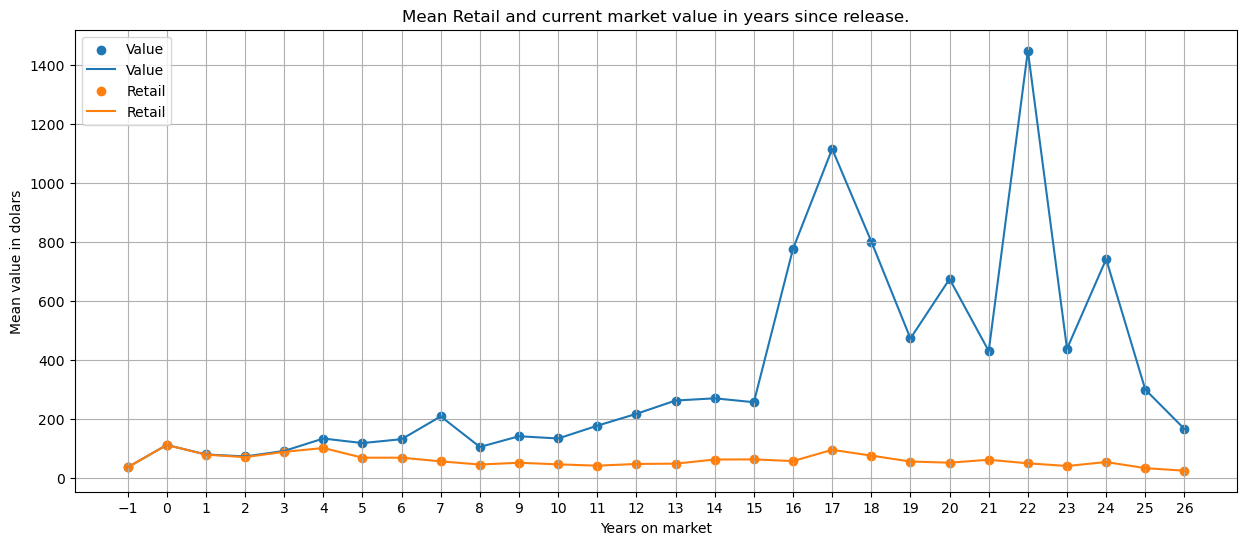

In [7]:
temp = data.groupby(['Years']).mean()[['Value', 'Retail']]

plt.figure(figsize=(15, 6))
plt.scatter(x = temp.index, y = 'Value', data = temp)
plt.plot('Value', data=temp)
plt.scatter(x = temp.index, y = 'Retail', data = temp)
plt.plot('Retail', data=temp)
plt.legend(loc = 'upper left')
plt.xlabel('Years on market')
plt.ylabel('Mean value in dolars')
plt.title('Mean Retail and current market value in years since release.')
plt.xticks(temp.index)
plt.grid(visible=True)
plt.show()

Powyższe punkty przedstawiają przeciętne ceny w dniu premiry i rynkowe w chwili obecnej zestawów dla poszczególnych lat. Zestawienie wskazuje na tendencję wzorstową ceny rynkowej wraz z upływem czasu. Im zestaw jest starszy, tym średnio rzecz biorąc jego cena będzie droższa. Rozumowanie pokrywa się z teorią ekonomiczną.

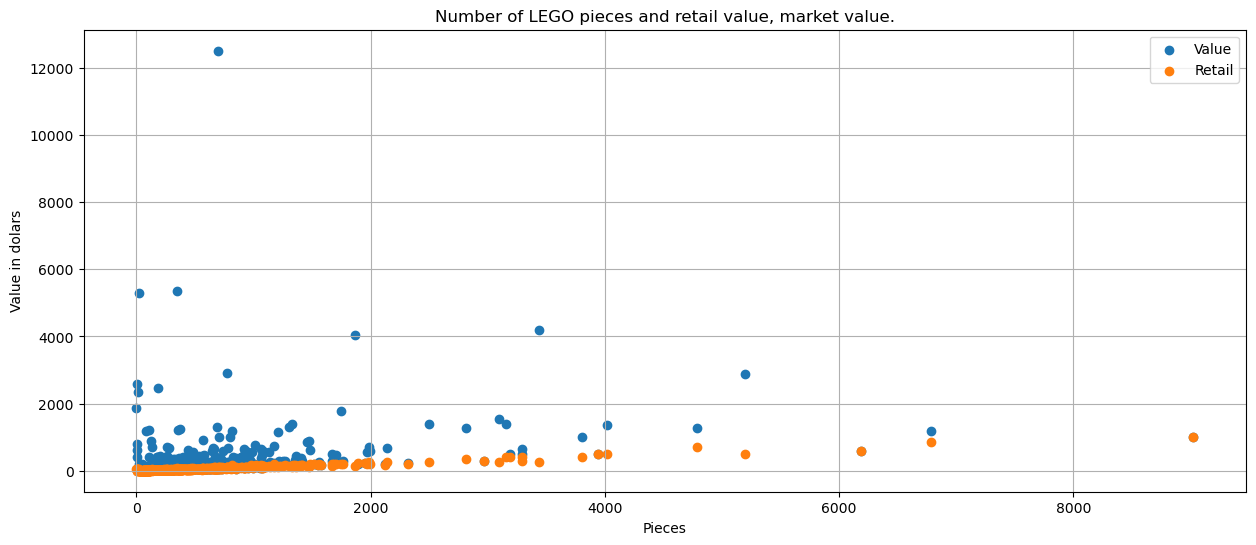

In [8]:
plt.figure(figsize=(15, 6))
plt.scatter(x = 'Pieces', y = 'Value', data = data)
plt.scatter(x = 'Pieces', y = 'Retail', data = data)
plt.legend(loc = 'upper right')
plt.xlabel('Pieces')
plt.ylabel('Value in dolars')
plt.title('Number of LEGO pieces and retail value, market value.')
plt.grid(visible=True)
plt.show()


Rozrzut cen detalicznych i rynkowych w porównaniu z liczbą elementów każdego z zestawu LEGO STAR WARS wskazuje na brak liniowej zależności dla cen rynkowych i na liniową zależność dla cen detalicznych. LEGO produkując większe zestawy oczekuje , że klient zapłaci większa kwotę, jednak w przypadku cen rynkowych brakuje tak oczywistej zależności. Prawdopodobne jest, że większy wpływ ma popularność i estetyka poszczególnych zestawów, niż sam ich rozmiar.

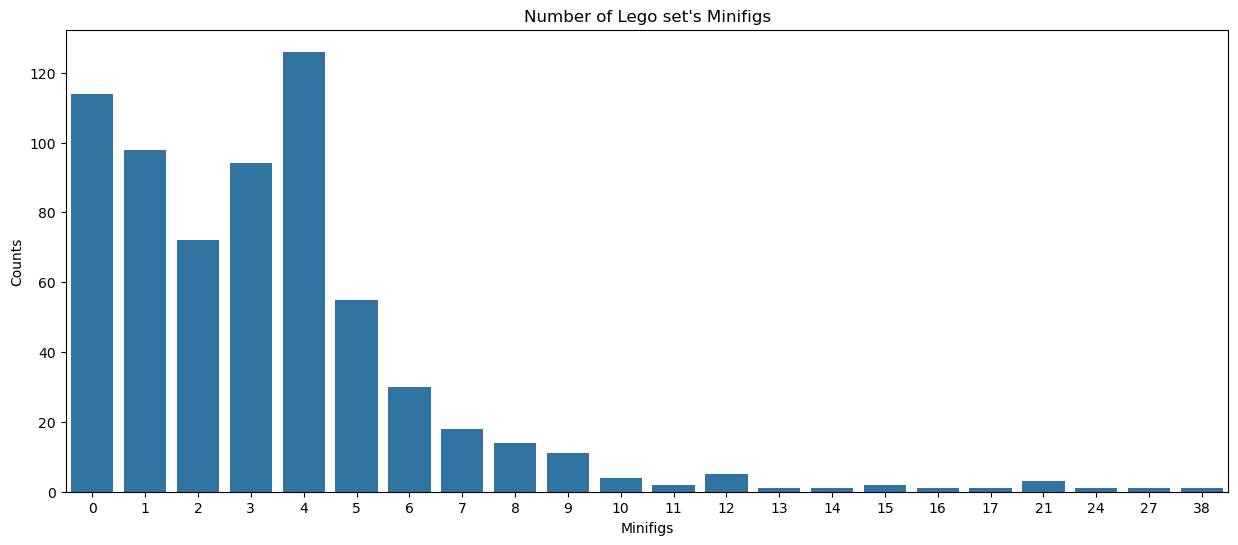

In [9]:
plt.figure(figsize=(15, 6))
sns.countplot(data, x = 'Minifigs')
plt.title("Number of Lego set's Minifigs")
plt.ylabel('Counts')
plt.xlabel('Minifigs')
plt.show()

Wykres kolumnowy ukazuje ilość zestawów zawierających daną liczbę minifigurek. W historii serii STAR WARS zdecydowanie dominują zestawy posiadające względnie mniejsze ilości minifigurek wahające się od 0 do 5 sztuk. 

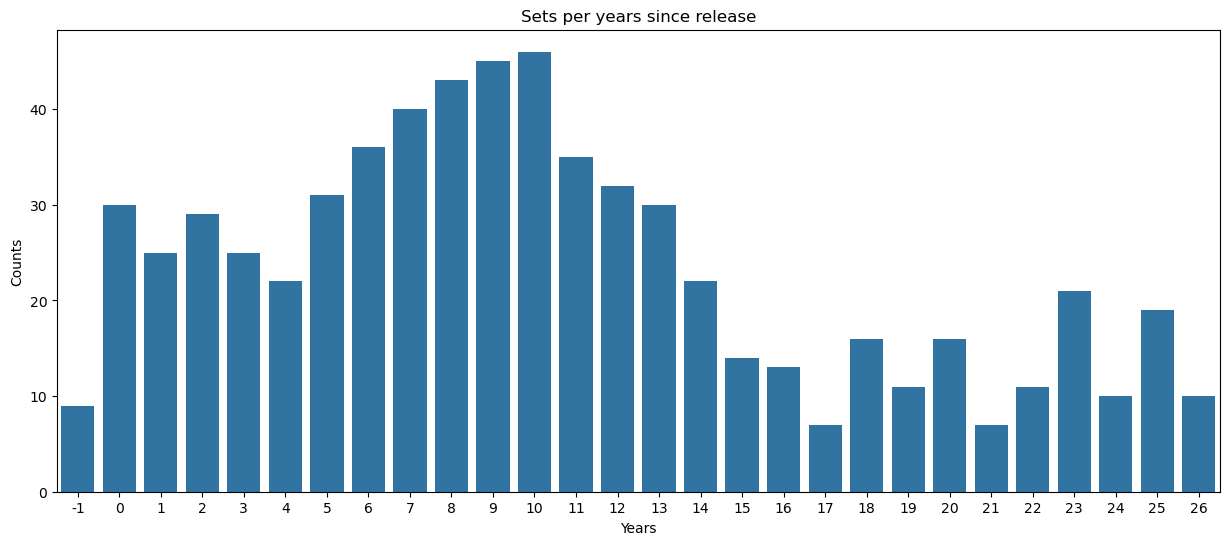

In [10]:
plt.figure(figsize=(15, 6))
sns.countplot(data, x = 'Years')
plt.title("Sets per years since release")
plt.ylabel('Counts')
plt.xlabel('Years')
plt.show()

Dzięki powyższemu wykresowi można dostrzec ‘lata świetności’ serii LEGO STAR WARS. Kolumny informują o ilości zestawów wypuszczonych na rynek w danym roku od roku 2025. Ostatnie kolumny wskazują na początek serii (pierwszy rok 1999) i wskazują na znacznie mniejsze ilości wypuszczanych zestawów. Nagły wzrost można zaobserwować około 15 lat temu, gdzie liczba zestawów wypuszczanych w danym roku zaczęła się niemalże podwajać. Nieoczekiwany spadek popularności serii można odnotować około 5-6 lat temu, co może być związane z brakiem kolejny wielkich kinowych premier, które w głównej mierze dostarczają nowości i inspiracji do produkowania kolejnych zestawów LEGO.

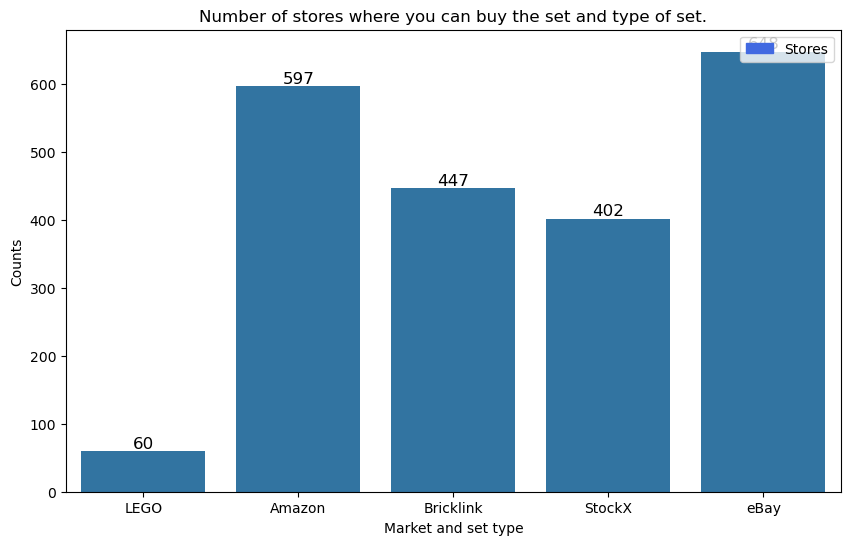

In [11]:
counts = data[['LEGO', 'Amazon', 'Bricklink', 'StockX', 'eBay']].sum()

plt.figure(figsize=(10, 6))
ax = sns.barplot(x=counts.index, y=counts.values)
for container in ax.containers:
    ax.bar_label(container, fmt='%d', fontsize=12)
legend_patches = [
    mpatches.Patch(color='royalblue', label='Stores')
]
plt.legend(handles=legend_patches, loc='upper right')
plt.xlabel('Market and set type')
plt.ylabel('Counts')
plt.title('Number of stores where you can buy the set and type of set.')
plt.show()

Do zrozumienia gdzie dostępne do kupienia są w obecnej chwili poszczególne zestawy pomoże powyższy wykres kolumnowy. Ukazuje on zliczone ilości wszystkich zestawów dostępnych na konkretnych sklepach internetowych. Na platformie LEGO STORE można zakupić wyłącznie zestawy obecne w dystrybucji, jednak zestawy starsze znaleźć można wyłącznie na giełdach i wielkich serwisach internetowych. Najpopularniejszymi miejscami gdzie zakupić można każdy z zestawów są Amazon i eBay. 

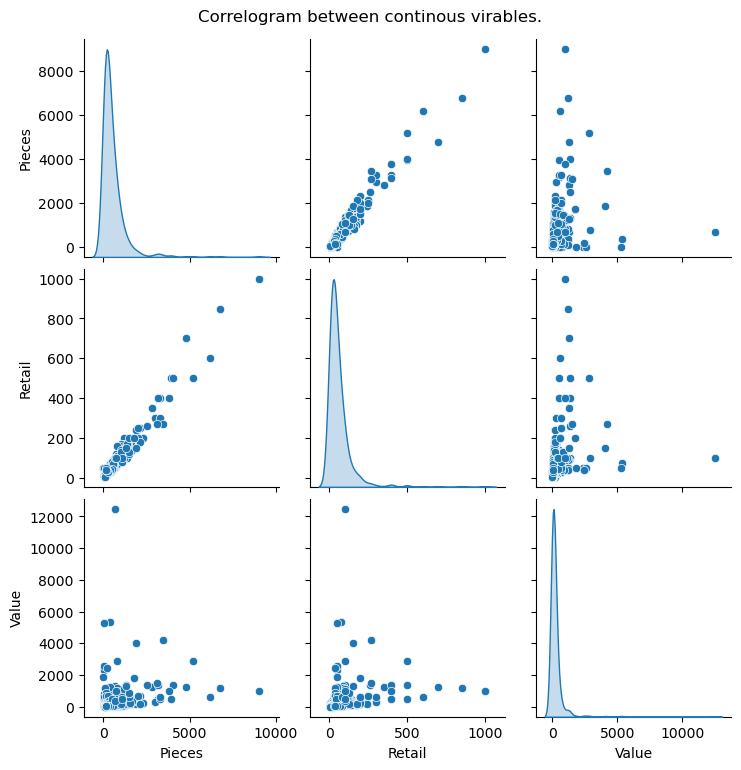

In [12]:
continous_data = data.loc[:,np.logical_not(data.columns.isin(['LEGO', 'Amazon', 'Bricklink', 'StockX', 'eBay', 'Years', 'Minifigs']))]

plot = sns.pairplot(continous_data, kind='scatter', diag_kind='kde')
plot.figure.suptitle('Correlogram between continous virables.', y=1.02)
plt.show()

Powyższy korelogram pomoże zrozumieć relację pomiędzy zmiennymi ciągłymi. Tak jak można było dostrzec wcześniej, występuje dodatnia korelacja liniowa pomiędzy ceną w dniu premiery, a ilością elementów w zestawie. Podobne relacje nie występują w tak podręcznikowej formie jak poprzednia. Brakuje wyraźnej tendencji między ceną rynkową, a liczba elementów lub ceną detaliczną.

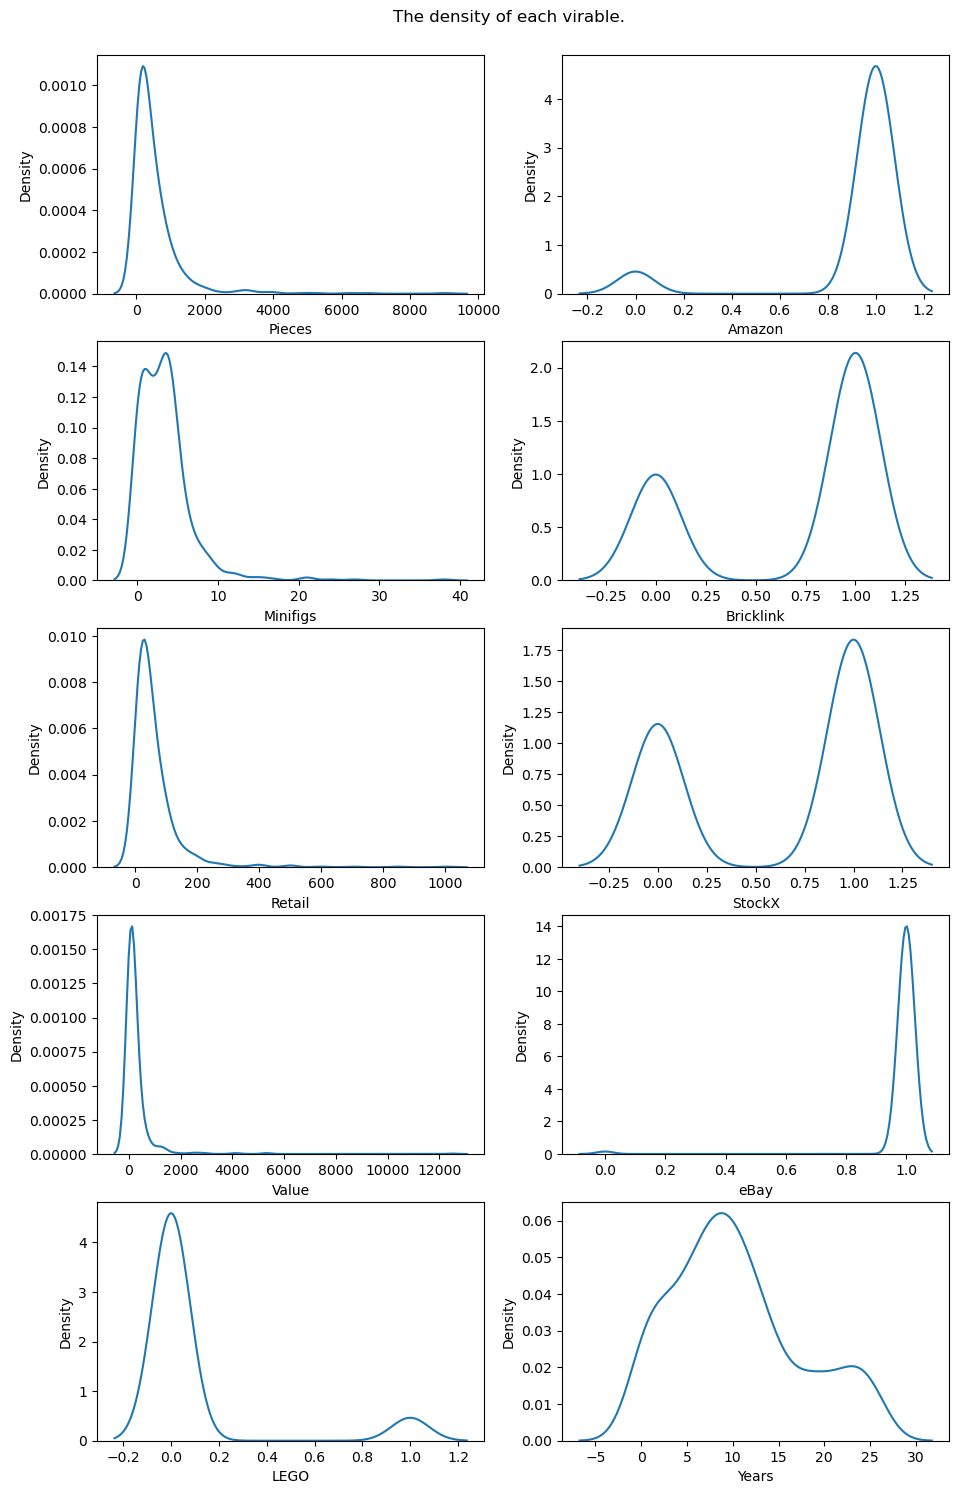

In [13]:
fig, axes = plt.subplots(5, 2, figsize=(11, 18))

for index, col in enumerate(data.columns):
    x_index = 0
    y_index = index

    if index >= 5:
        x_index = 1
        y_index -= 5
    
    sns.kdeplot(data=data, x=col, ax=axes[y_index, x_index])

fig.suptitle('The density of each virable.', y=0.905)
plt.show()
    


Wykresy gęstości każdej ze zmiennych zdradzą coś więcej o przedziałach wartości z jakimi jest do czynienia. Z racji typu danych określonych wyłącznie na dodatnim przedziale liczb rzeczywistych występują tutaj grube prawe ogony (asymetria). Zmienne takie jak ilość elementów, czy zestawów w danym roku zostały już wcześniej ukazane w innej formie. Wykresy dotyczące dostępności zestawów w najpopularniejszych sklepach internetowych informują jaki jest stosunek zestawów dostępnych w danym serwisie, to tego ilu zestawów w nim brakuje. Zmienne dotyczące liczby elementów i ceny rynkowej są stosunkowo podobne. Występuje duża koncentracja wartości na przedziale 0-1000 i długi prawy ogon. Zmienna ceny detalicznej posiada koncentrację wartości na przedziale 0-200. Te trzy zmienne prawdopodobnie będą wymagać standaryzacji lub skalowania, aby nie zaburzyć estymacji modeli. 